# SmartCart
## E-commerce Customer Segmentation System

In [361]:
import pandas as pd

In [362]:
df= pd.read_csv("smartcart_customers.csv")

In [363]:
df.sample(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
1065,4415,1961,Graduation,Married,16860.0,1,1,12-09-2012,19,10,...,3,3,14,3,1,1,3,7,0,0
599,3537,1981,Graduation,Together,31089.0,1,0,17-08-2012,57,31,...,2,8,4,3,3,0,4,8,0,0
657,946,1958,2n Cycle,Together,26490.0,0,0,22-09-2012,92,45,...,21,20,25,2,3,1,5,6,0,0
1471,4864,1977,Graduation,Married,34380.0,1,0,02-05-2013,68,72,...,13,1,24,4,4,1,3,8,0,0
1325,9212,1962,Master,Married,72828.0,0,1,14-02-2013,17,1205,...,19,14,205,6,6,3,13,7,0,0
1558,6642,1961,Graduation,Divorced,27215.0,2,1,23-01-2013,50,30,...,8,9,28,4,2,1,4,6,0,0
1602,2565,1955,Master,Divorced,70638.0,0,0,01-06-2013,69,1016,...,16,12,63,1,4,5,10,3,0,0
2145,9790,1957,Graduation,Single,78499.0,0,0,23-11-2013,12,912,...,47,36,97,1,11,3,4,4,0,1
2232,8080,1986,Graduation,Single,26816.0,0,0,17-08-2012,50,5,...,3,4,3,1,0,0,3,4,0,0
1969,4331,1978,Master,Together,85738.0,0,0,23-01-2014,41,913,...,17,26,13,1,3,6,11,1,0,0


In [364]:
df.shape

(2240, 22)

In [365]:
df.info

<bound method DataFrame.info of          ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
0      5524        1957  Graduation         Single  58138.0        0   
1      2174        1954  Graduation         Single  46344.0        1   
2      4141        1965  Graduation       Together  71613.0        0   
3      6182        1984  Graduation       Together  26646.0        1   
4      5324        1981         PhD        Married  58293.0        1   
...     ...         ...         ...            ...      ...      ...   
2235  10870        1967  Graduation        Married  61223.0        0   
2236   4001        1946         PhD       Together  64014.0        2   
2237   7270        1981  Graduation       Divorced  56981.0        0   
2238   8235        1956      Master       Together  69245.0        0   
2239   9405        1954         PhD        Married  52869.0        1   

      Teenhome Dt_Customer  Recency  MntWines  ...  MntFishProducts  \
0            0  04-09-2012      

In [366]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

## Handle missing data

We inspect the dataset and resolve any missing fields. The "Income" feature contains 24 missing entries, which we handle using median imputation.

In [367]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [368]:
df.isna().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

## Feature Engineering

To enhance models, we derive more intuitive attributes from raw columns:
* **Age Calculation:** Calculated using the current benchmark year (2026).
* **Customer Tenure:** Total loyalty period in days from the registration date.
* **Total Spending:** Consolidated monetary spending across all categories.
* **Total Children:** Sum of kids and teenagers present in the household.
* **Categorical Simplification:** Collapsing sparse categorical values in `Education` and `Marital_Status` into standardized groups.

In [369]:
df['Age']=2026-df['Year_Birth']

df['Dt_Customer']=pd.to_datetime(df['Dt_Customer'], dayfirst=True)
reference= df['Dt_Customer'].max()
df['Customer_tenure_days']= (reference- df['Dt_Customer']).dt.days

In [370]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [371]:
df['total_amt_spend']= df['MntWines']+df['MntFishProducts']+df['MntFruits']+df['MntMeatProducts']+df['MntSweetProducts']+df['MntGoldProds']

df['total_children']=df['Kidhome']+df['Teenhome']


In [372]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,total_amt_spend,total_children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [373]:
df['Education'].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [374]:
df['Education']=df['Education'].replace({
    'Graduation' : 'Graduate', 'PhD' : 'Postgraduate', 'Master' : 'Postgraduate', '2n Cycle':'Undergraduate', 'Basic':'Undergraduate'
})

In [375]:
df['Education'].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [376]:
df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [377]:
df['Partner_Status']=df['Marital_Status'].replace({
    'Married' : 'Partner', 'Together' : 'Partner', 'Single' : 'Alone', 'Divorced':'Alone', 'Widow':'Alone',
    'Alone' : 'Alone', 'Absurd' : 'Alone', 'YOLO' : 'Alone'
})

In [378]:
df['Partner_Status'].value_counts()

Partner_Status
Partner    1444
Alone       796
Name: count, dtype: int64

## Drop columns

In [379]:
drop_cols=['ID','Year_Birth','Marital_Status','Kidhome',
       'Teenhome', 'Dt_Customer','MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds']

df_cleaned=df.drop(drop_cols, axis=1)

In [380]:
df_cleaned

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,total_amt_spend,total_children,Partner_Status
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,Graduate,61223.0,46,2,9,3,4,5,0,0,59,381,1341,1,Partner
2236,Postgraduate,64014.0,56,7,8,2,5,7,0,0,80,19,444,3,Partner
2237,Graduate,56981.0,91,1,2,3,13,6,0,0,45,155,1241,0,Alone
2238,Postgraduate,69245.0,8,2,6,5,10,3,0,0,70,156,843,1,Partner


## Handle outliers

Additionally, based on distribution plots, we filter extreme anomalies (e.g., Age > 90 and extreme Income spikes) to avoid skewing distance computations.

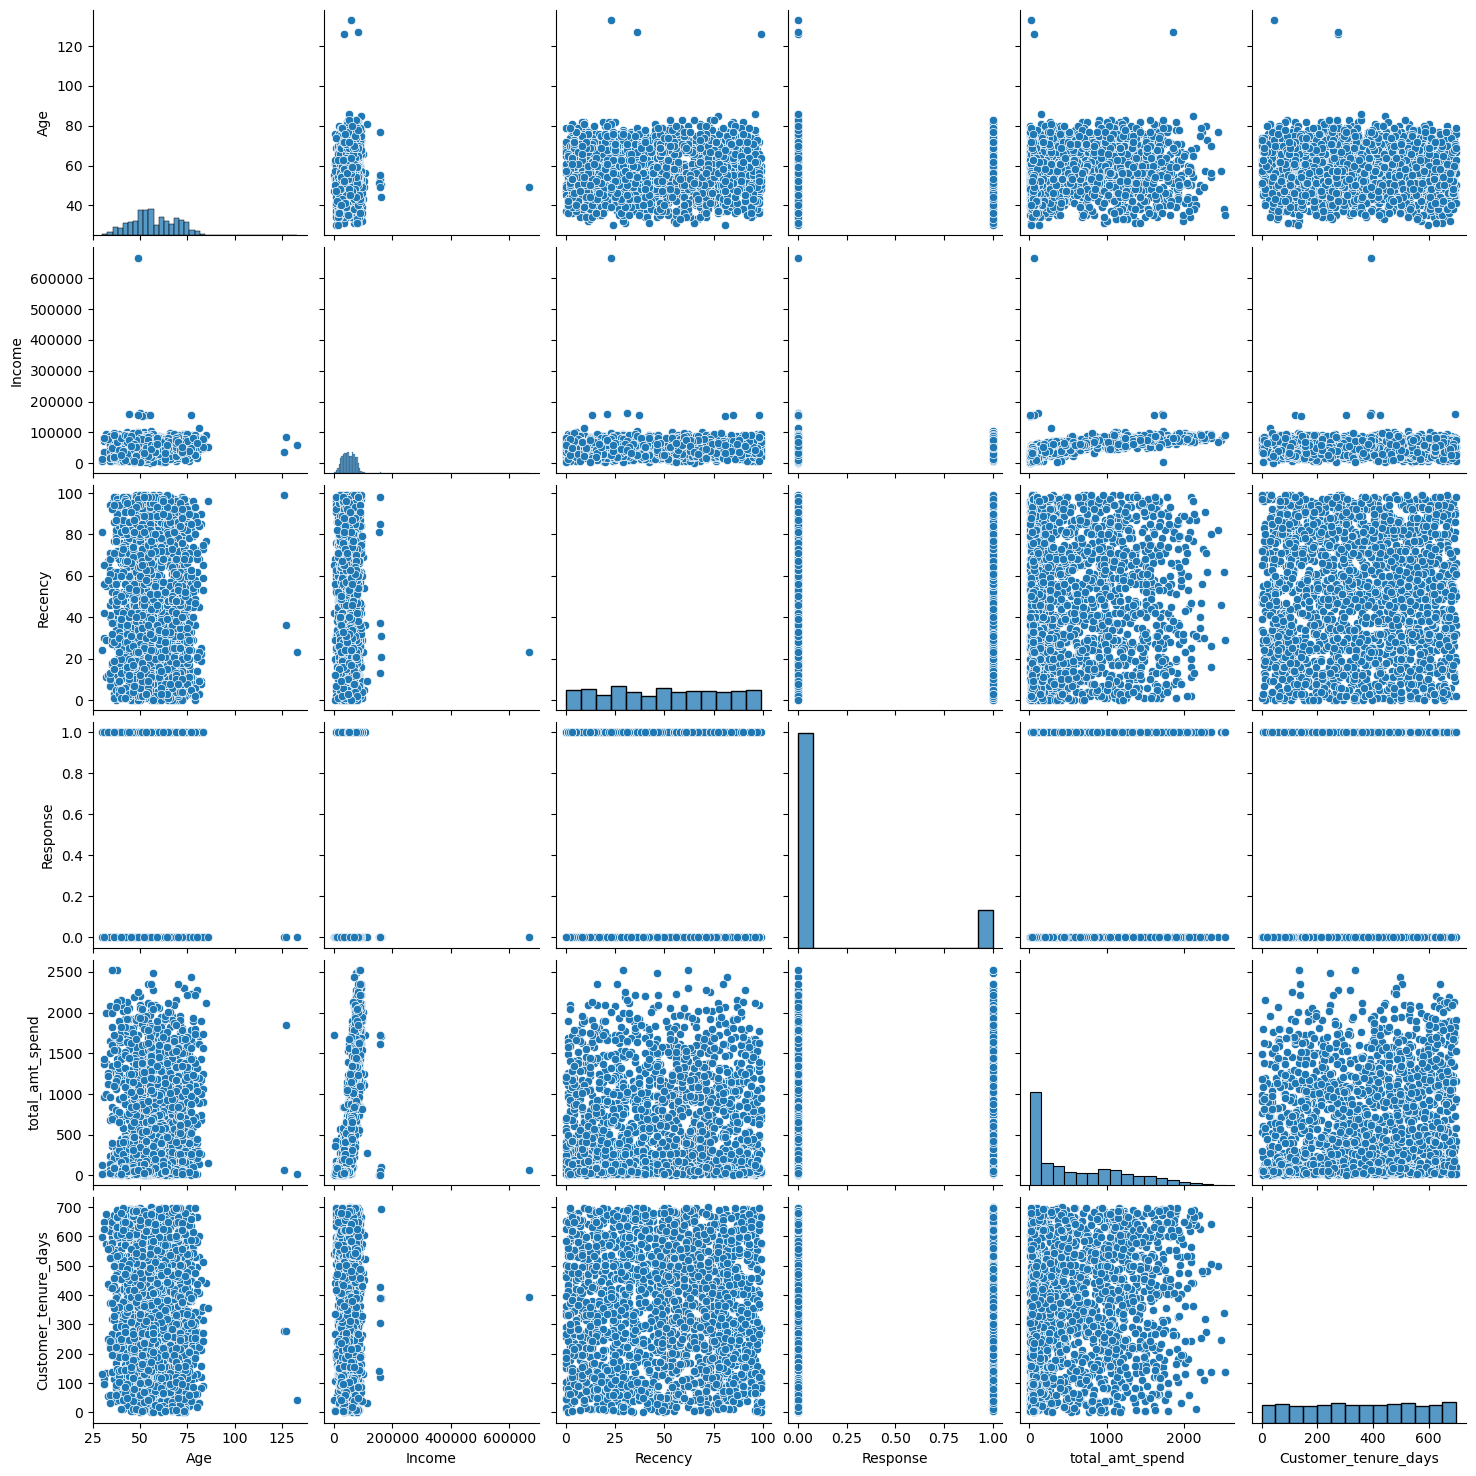

In [381]:
import seaborn as sns
import matplotlib.pyplot as plt

cols=['Age', 'Income', 'Recency','Response','total_amt_spend','Customer_tenure_days']

sns.pairplot(df_cleaned[cols])


In [382]:
print('datasize with outliers', len(df_cleaned))

df_cleaned=df_cleaned[(df_cleaned['Age']<=90)]
df_cleaned=df_cleaned[(df_cleaned['Income']<600_000)]

print('datasize with outliers', len(df_cleaned))

datasize with outliers 2240
datasize with outliers 2236


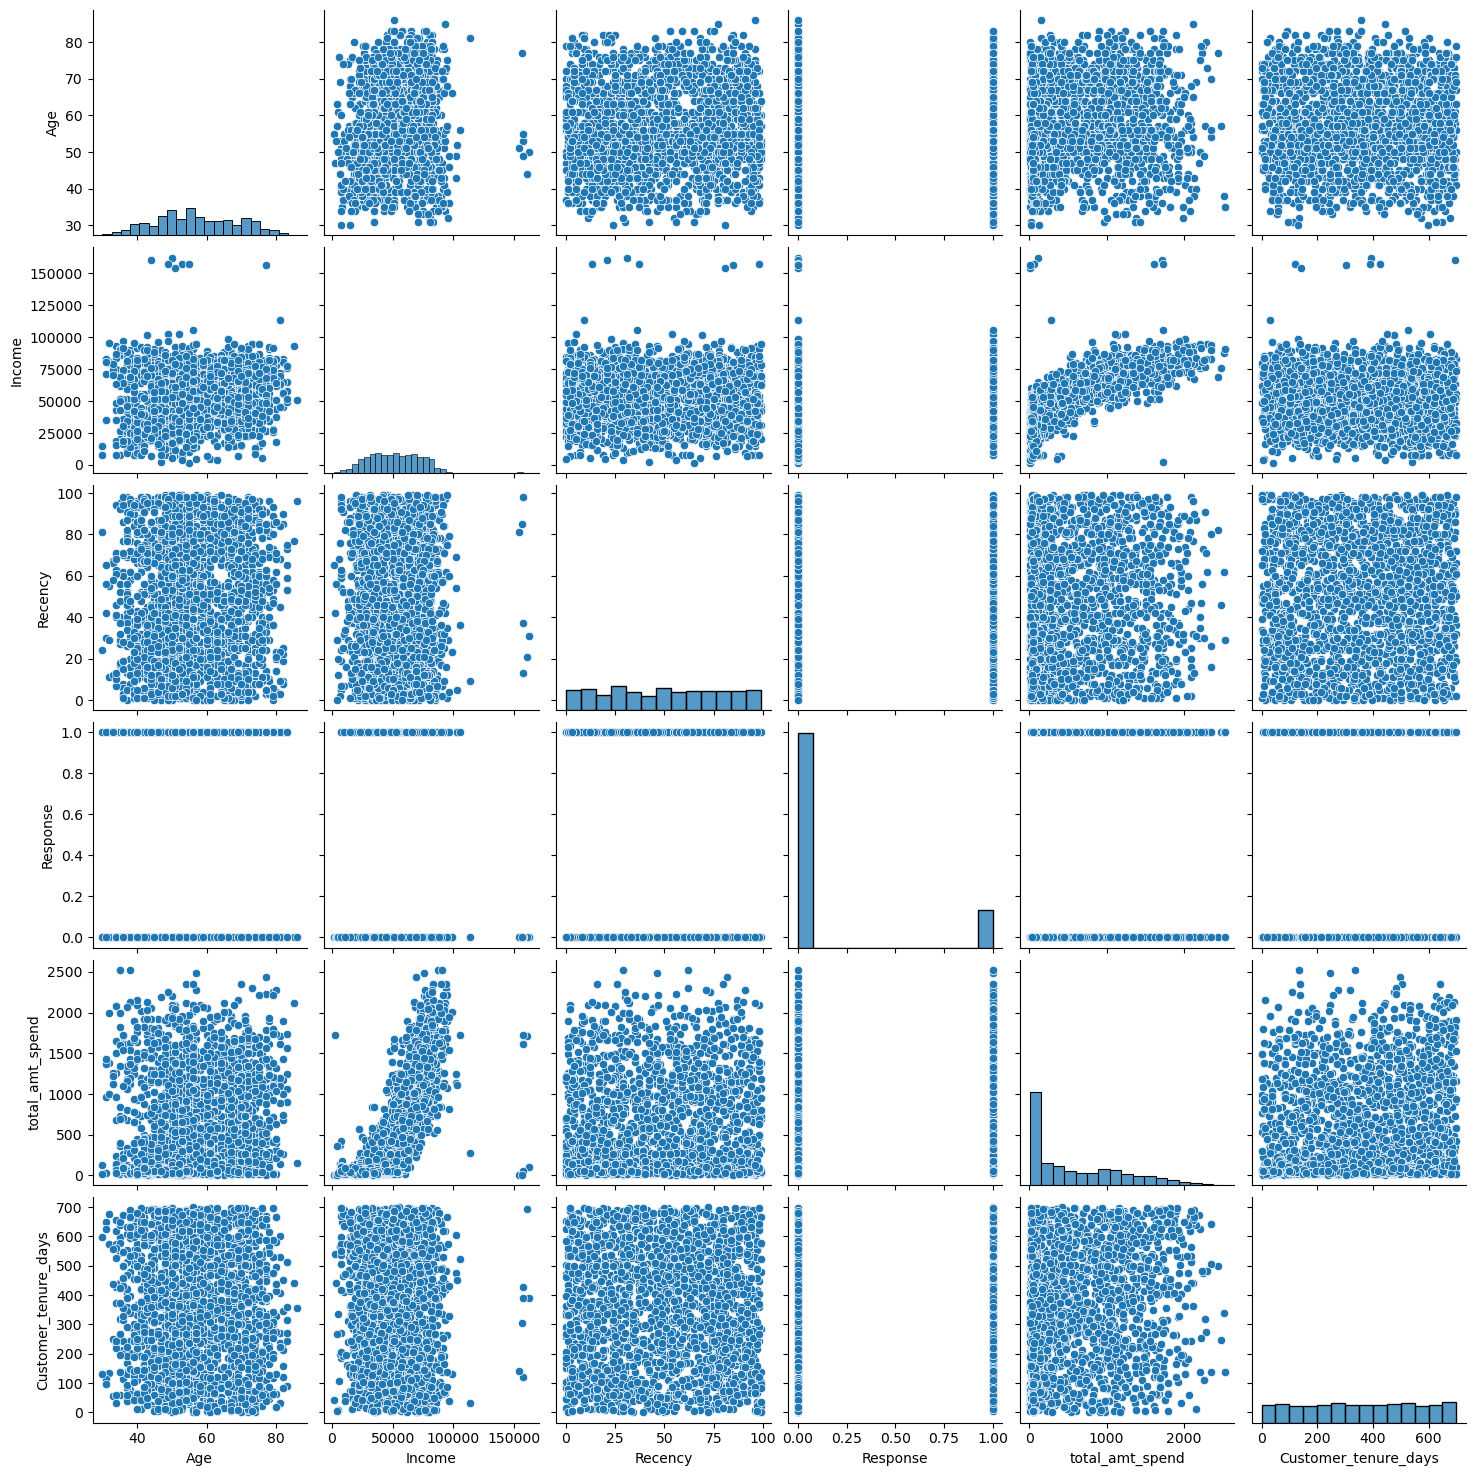

In [383]:
sns.pairplot(df_cleaned[cols])

## Heatmap

<Axes: >

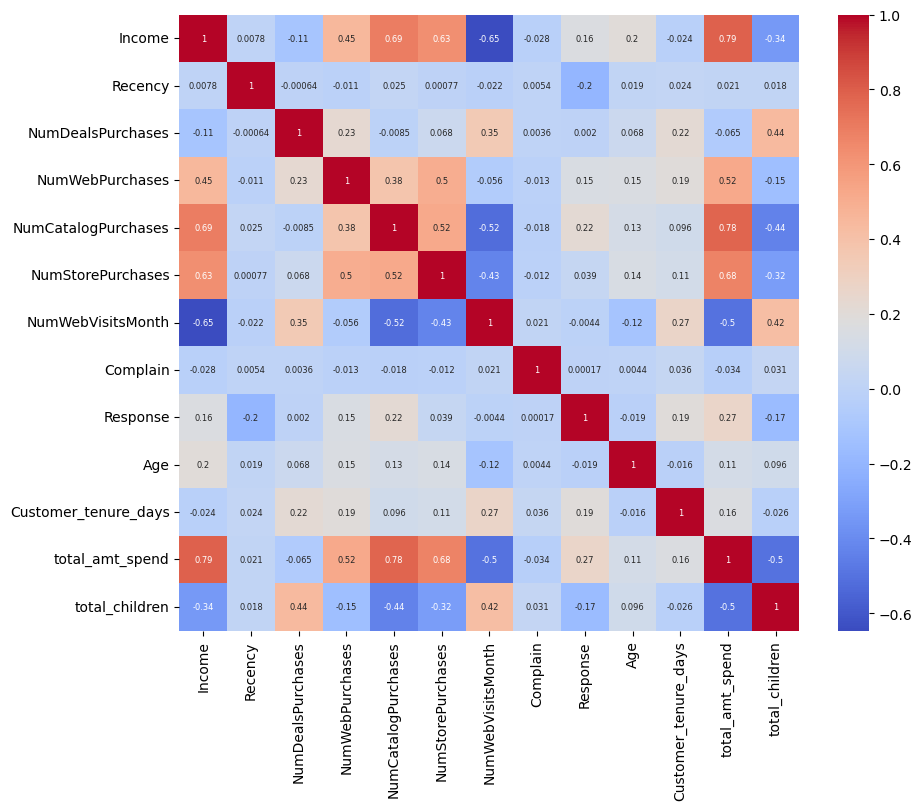

In [384]:
corr= df_cleaned.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={'size':6},
    cmap='coolwarm'
)

### Key Insights from the Correlation Heatmap

#### 1. Income vs Spending (r = 0.79)
- Higher-income customers spend more on SmartCart.
- They also make more catalog and store purchases.
- These are the company's most valuable customers.

#### 2. Children vs Spending (r = -0.50)
- Customers with more children spend less overall.
- However, they make more purchases during discounts and offers.
- They are more price-sensitive.

#### 3. Web Visits vs Purchases (r = -0.65)
- Customers with frequent website visits usually spend less.
- High-income customers visit less often but make higher-value purchases.
- More visits do not always mean more sales.

#### 4. Web Purchases vs Spending (r = 0.52)
- More web purchases are associated with higher spending.
- Customers across different income groups prefer shopping online.

### Overall Conclusion
Income is the strongest factor affecting customer spending. Families with more children are more discount-driven, while frequent website visitors do not always become buyers. These insights can help SmartCart improve marketing strategies and target the right customer segments.

In [385]:
corr

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,total_amt_spend,total_children
Income,1.000000,0.007829,-0.107169,0.450584,0.693781,0.628075,-0.646382,-0.027871,0.161121,0.198835,-0.023677,0.789375,-0.340550
Recency,0.007829,1.000000,-0.000638,-0.010776,0.025226,0.000771,-0.021850,0.005361,-0.198781,0.019396,0.024238,0.020842,0.017826
NumDealsPurchases,-0.107169,-0.000638,1.000000,0.233971,-0.008510,0.068418,0.347216,0.003636,0.002017,0.068286,0.218009,-0.064831,0.439682
NumWebPurchases,0.450584,-0.010776,0.233971,1.000000,0.378049,0.502227,-0.056204,-0.013250,0.148390,0.153873,0.191211,0.519948,-0.146429
NumCatalogPurchases,0.693781,0.025226,-0.008510,0.378049,1.000000,0.518788,-0.520376,-0.018304,0.220813,0.125285,0.095836,0.778343,-0.439631
NumStorePurchases,0.628075,0.000771,0.068418,0.502227,0.518788,1.000000,-0.429857,-0.011563,0.038702,0.139237,0.109727,0.675460,-0.321729
NumWebVisitsMonth,-0.646382,-0.021850,0.347216,-0.056204,-0.520376,-0.429857,1.000000,0.020796,-0.004397,-0.117498,0.272105,-0.499909,0.417908
Complain,-0.027871,0.005361,0.003636,-0.013250,-0.018304,-0.011563,0.020796,1.000000,0.000167,0.004450,0.035685,-0.033784,0.031480
Response,0.161121,-0.198781,0.002017,0.148390,0.220813,0.038702,-0.004397,0.000167,1.000000,-0.018557,0.194232,0.265615,-0.169451
Age,0.198835,0.019396,0.068286,0.153873,0.125285,0.139237,-0.117498,0.004450,-0.018557,1.000000,-0.016451,0.113618,0.095512


## Encoding

In [386]:
from sklearn.preprocessing import OneHotEncoder

ohe= OneHotEncoder(sparse_output=False, handle_unknown='ignore')  
ohe_encoded= ohe.fit_transform(df_cleaned[['Education','Partner_Status']])
encoded_cols = pd.DataFrame(
    ohe_encoded, 
    columns=ohe.get_feature_names_out(['Education','Partner_Status']),
    index=df_cleaned.index)

In [387]:
df_cleaned = pd.concat([df_cleaned.drop(['Education','Partner_Status'], axis=1), encoded_cols], axis=1)

In [388]:
df_cleaned

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,total_amt_spend,total_children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Partner_Status_Alone,Partner_Status_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,2,9,3,4,5,0,0,59,381,1341,1,1.0,0.0,0.0,0.0,1.0
2236,64014.0,56,7,8,2,5,7,0,0,80,19,444,3,0.0,1.0,0.0,0.0,1.0
2237,56981.0,91,1,2,3,13,6,0,0,45,155,1241,0,1.0,0.0,0.0,1.0,0.0
2238,69245.0,8,2,6,5,10,3,0,0,70,156,843,1,0.0,1.0,0.0,0.0,1.0


## Scaling

In [389]:
from sklearn.preprocessing import StandardScaler

X=df_cleaned
scaler= StandardScaler()
X_scaled=scaler.fit_transform(X)

In [390]:
X_scaled.shape

(2236, 18)

## Visualization

In [391]:
from sklearn.decomposition import PCA

pca=PCA(n_components=2, random_state=42)
X_pca= pca.fit_transform(X_scaled)

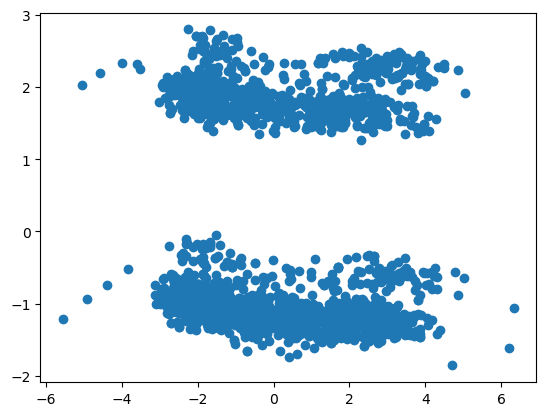

In [392]:
plt.scatter(
    X_pca[:,0], X_pca[:,1]
)


In [393]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454])

In [394]:
pca=PCA(n_components=3, random_state=42)
X_pca= pca.fit_transform(X_scaled)

pca.explained_variance_ratio_


array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d projection')

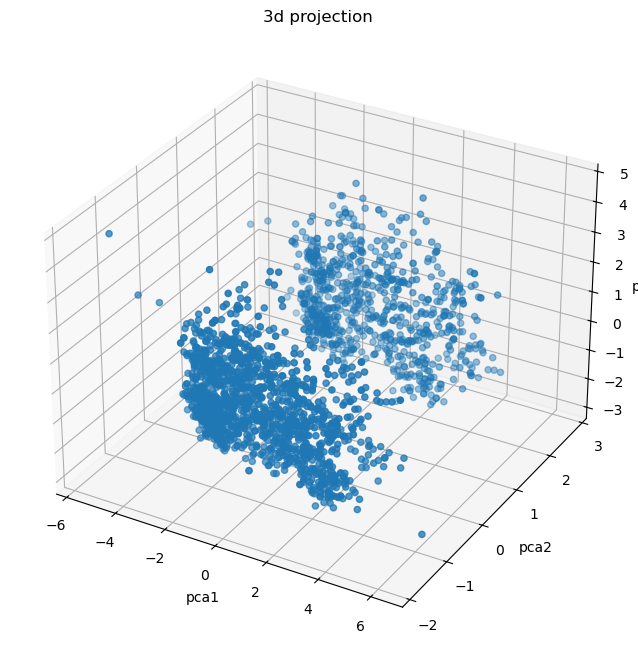

In [395]:
fig= plt.figure(figsize=(10,8))
ax=fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2])

ax.set_xlabel('pca1')
ax.set_ylabel('pca2')
ax.set_zlabel('pca3')
ax.set_title('3d projection')


Since our data space contains 18 features post-encoding, human visualization is impossible without aggregation. 


## Clustering

### analyze k values by elbow method

In [396]:

from kneed import KneeLocator
from sklearn.cluster import KMeans

wcss=[]
for k in range(1, 11):
    kmeans= KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    kth_wcss=kmeans.inertia_
    # print(kth_wcss)
    wcss.append(kth_wcss)




In [397]:
from kneed import KneeLocator

kl=KneeLocator(x=range(1,11), y=wcss, curve="convex", direction="decreasing")
print("optimal k=", kl.knee)



optimal k= 4


Text(0.5, 1.0, 'elbow score')

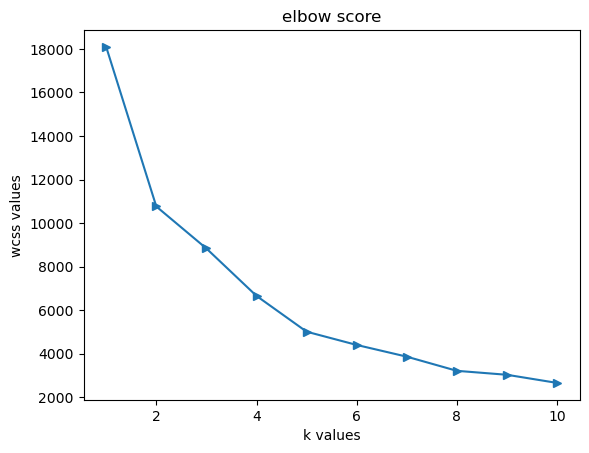

In [398]:
plt.plot(
    range(1,11),
    wcss,
    marker='>'
)

plt.xlabel("k values")
plt.ylabel("wcss values")
plt.title("elbow score")

### analyze k values by silhouette_score

In [399]:

from sklearn.metrics import silhouette_score

ss=[]
for k in range(2, 11):
    kmeans= KMeans(n_clusters=k, random_state=42)
    labels=kmeans.fit_predict(X_pca)
    kth_ss=silhouette_score(X_pca, labels)
    # print(kth_wcss)
    ss.append(kth_ss)

Text(0.5, 1.0, 'silhoutte score')

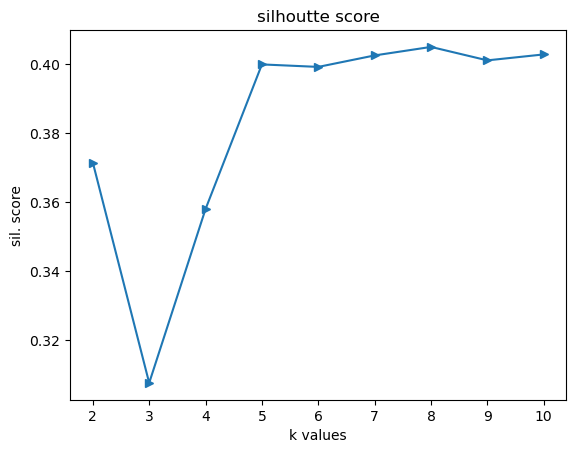

In [400]:
plt.plot(
    range(2,11),
    ss,
    marker='>'
)

plt.xlabel("k values")
plt.ylabel("sil. score")
plt.title("silhoutte score")

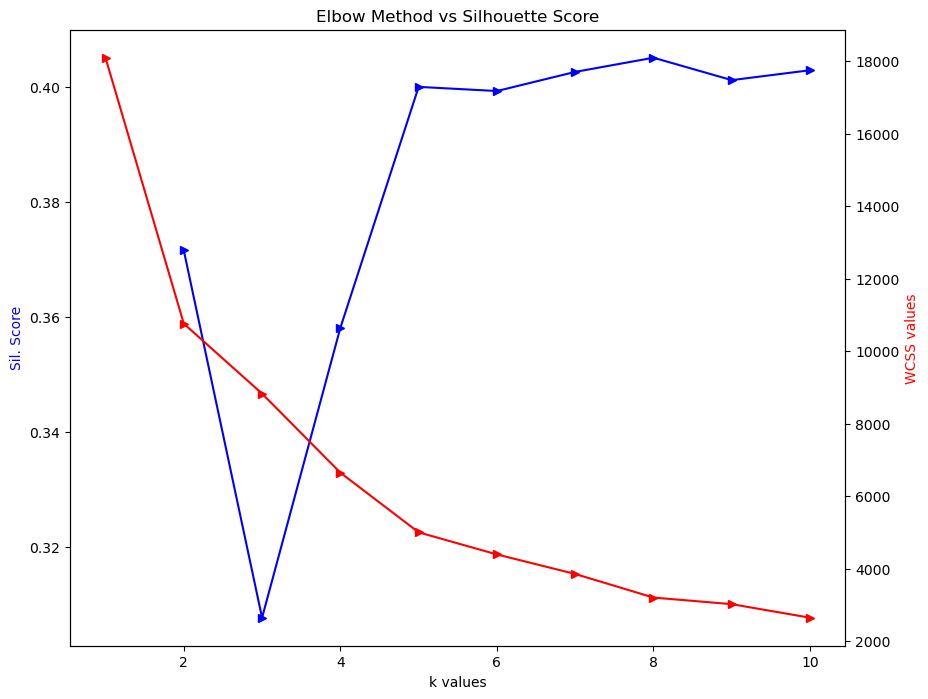

In [401]:
##combined plot

fig, ax1 = plt.subplots(figsize=(10,8))
ax1.plot(range(2, 11), ss, marker='>', color='b')
ax1.set_xlabel("k values")
ax1.set_ylabel("Sil. Score", color='b')


ax2=ax1.twinx()
ax2.plot(range(1, 11), wcss, marker='>', color='r')
ax2.set_ylabel("WCSS values", color='r')


plt.title("Elbow Method vs Silhouette Score")
plt.show()


Based on both the Elbow Method and Silhouette Analysis, **k = 4** was selected as the optimal number of clusters. The Elbow Method shows that the curve reaches its main turning point at k = 4, indicating that adding more clusters provides only a small improvement. The Silhouette Score also remains stable at k = 4, suggesting that the clusters are well-separated and meaningful.

## Kmeans clustering

In [402]:
kmeans= KMeans(n_clusters=4, random_state=42)
labels=kmeans.fit_predict(X_pca)

Text(0.5, 0.92, '3d projection')

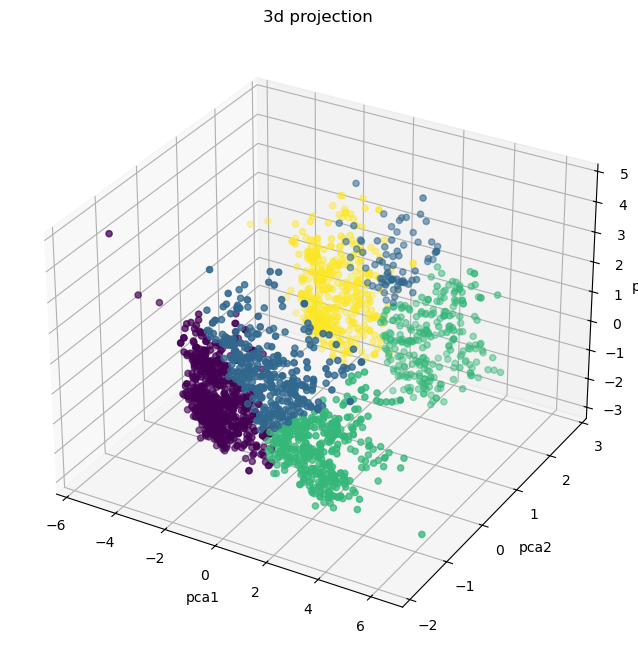

In [403]:
fig= plt.figure(figsize=(10,8))
ax=fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=labels)

ax.set_xlabel('pca1')
ax.set_ylabel('pca2')
ax.set_zlabel('pca3')
ax.set_title('3d projection')

## Agglomerative Clustering

In [404]:
from sklearn.cluster import AgglomerativeClustering
ac= AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_agg=ac.fit_predict(X_pca)

Text(0.5, 0.92, '3d projection')

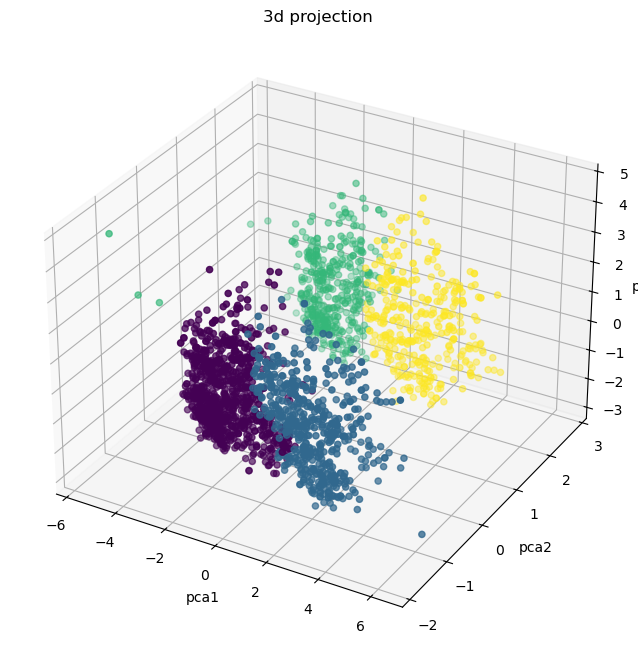

In [405]:
fig= plt.figure(figsize=(10,8))
ax=fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=labels_agg)

ax.set_xlabel('pca1')
ax.set_ylabel('pca2')
ax.set_zlabel('pca3')
ax.set_title('3d projection')

## DBSCAN

In [406]:
from sklearn.cluster import DBSCAN

dbscan =DBSCAN()
labels_db=dbscan.fit_predict(X_pca)


Text(0.5, 0.92, '3d projection')

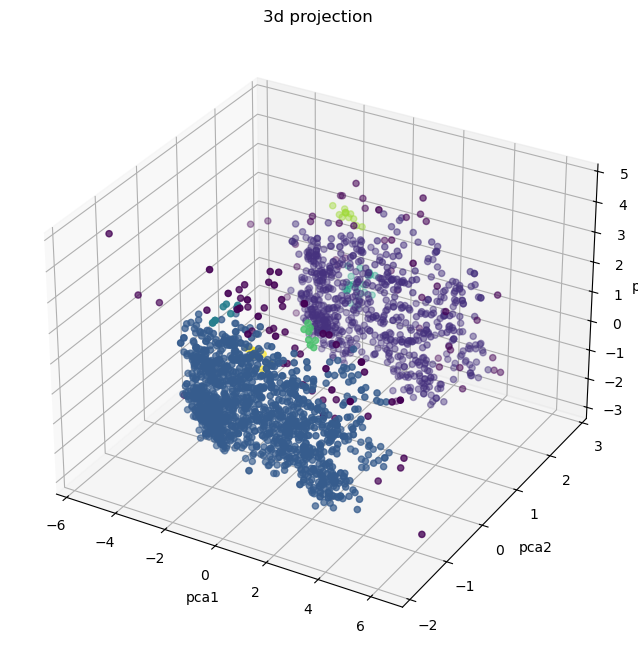

In [407]:
fig= plt.figure(figsize=(10,8))
ax=fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=labels_db)

ax.set_xlabel('pca1')
ax.set_ylabel('pca2')
ax.set_zlabel('pca3')
ax.set_title('3d projection')

### algorithm selection
We compared **K-Means**, **Agglomerative Hierarchical Clustering**, and **DBSCAN** on the PCA-transformed dataset to identify the best clustering approach. K-Means created meaningful clusters but assumed spherical cluster shapes, leading to some overlap. DBSCAN struggled with the dataset's density, grouping most customers into a single cluster or marking important points as noise. In contrast, **Agglomerative Hierarchical Clustering** produced the clearest and most well-separated clusters. Therefore, it was selected as the final model because it provides accurate customer segmentation into four distinct groups--making the results more reliable and useful for targeted marketing strategies.

## Characterization of clusters

In [415]:
df_cleaned['cluster_labels']= labels_agg
X['cluster_labels']= labels_agg

In [409]:
df_cleaned

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,total_amt_spend,total_children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Partner_Status_Alone,Partner_Status_Partner,cluster_labels
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,2,9,3,4,5,0,0,59,381,1341,1,1.0,0.0,0.0,0.0,1.0,0
2236,64014.0,56,7,8,2,5,7,0,0,80,19,444,3,0.0,1.0,0.0,0.0,1.0,0
2237,56981.0,91,1,2,3,13,6,0,0,45,155,1241,0,1.0,0.0,0.0,1.0,0.0,3
2238,69245.0,8,2,6,5,10,3,0,0,70,156,843,1,0.0,1.0,0.0,0.0,1.0,1


<Axes: xlabel='cluster_labels', ylabel='count'>

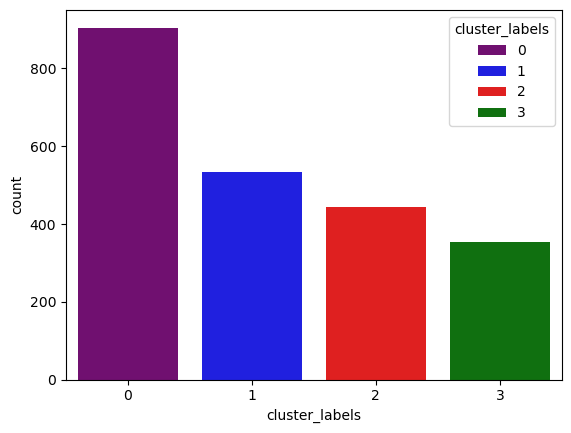

In [414]:
sns.countplot(x=df_cleaned['cluster_labels'], hue=df_cleaned['cluster_labels'], palette=['purple', 'blue', 'red', 'green'])

<Axes: xlabel='total_amt_spend', ylabel='Income'>

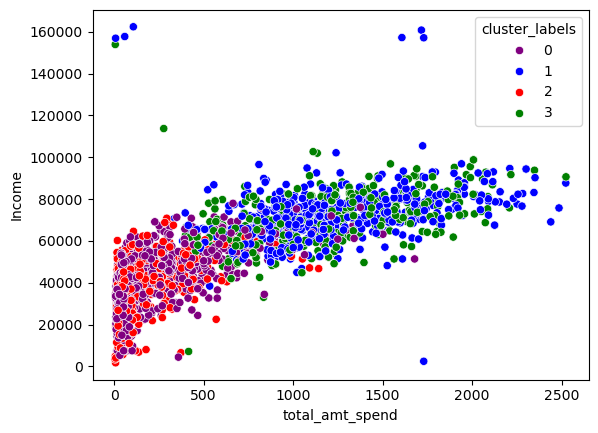

In [413]:
## income & spending patterns

sns.scatterplot(x=df_cleaned['total_amt_spend'], y=df_cleaned['Income'] , hue=df_cleaned['cluster_labels'], palette=['purple', 'blue', 'red', 'green'])

**Cluster 0 (Purple):** Customers with 'low to moderate income' and 'low to moderate spending'. They are average shoppers with moderate purchasing behavior.

**Cluster 1 (Blue):** Customers with 'high income' and 'high spending'. These are premium customers who contribute significantly.

**Cluster 2 (Red):** Customers with 'low income' and 'low spending'. They are budget-conscious shoppers who make fewer and lower-value purchases.

**Cluster 3 (Green):** Customers with 'moderate to high income' and 'high spending'. They are valuable customers with strong purchasing power, though slightly below the premium segment.



## cluster summary

In [417]:
cluster_summary=X.groupby('cluster_labels').mean()
print(cluster_summary)

                      Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster_labels                                                                
0               39680.580110  48.914917           2.594475         3.153591   
1               72808.445693  49.202247           1.958801         5.687266   
2               36960.143018  48.319820           2.594595         2.713964   
3               70722.681303  50.504249           1.855524         5.790368   

                NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  \
cluster_labels                                                              
0                          0.969061           4.143646           6.307182   
1                          5.498127           8.659176           3.580524   
2                          0.837838           3.623874           6.659910   
3                          5.014164           8.430595           3.728045   

                Complain  Response        Age  Customer_tenure

## Cluster 0 – Purple (Family Shoppers)

* More children
* Poor campaign response
* Mostly living with a partner
* High web visits
* Low store, catalog, and web purchases

**(Family Shoppers)** => SmartCart can offer discounts, coupons, and family-oriented deals to increase their engagement with the brand.

---

## Cluster 1 – Blue (Premium Customers)

* Fewer children
* Slightly higher age
* Average campaign response
* Mostly living with a partner
* Low web visits
* High store, catalog, and web purchases

**(Premium Customers)** => SmartCart can offer loyalty programs, exclusive rewards, and premium memberships to increase their engagement with the brand.

---

## Cluster 2 – Red (Single Parents / Digital Browsers)

* More children
* Average campaign response
* Mostly living alone
* High web visits
* Very low store, catalog, and web purchases

**(Single Parents / Digital Browsers)** => SmartCart can offer heavy discounts, coupons, and seasonal sales to encourage more purchases and increase engagement.

---

## Cluster 3 – Green (High-Value Singles / Best ROI)

* Fewer children
* Slightly higher age
* Best campaign response
* Mostly living alone
* Low web visits
* High store, catalog, and web purchases

**(High-Value Singles / Best ROI)** => SmartCart can offer personalized recommendations, premium services, and VIP benefits to strengthen customer loyalty and engagement.
